In [24]:
import pandas as pd

# Load datasets
orders = pd.read_csv("../Source data/OListDatasets/olist_orders_dataset.csv")
order_items = pd.read_csv("../Source data/OListDatasets/olist_order_items_dataset.csv")

# Convert purchase timestamp to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Merge order_items with orders to attach customer_id and timestamp
order_data = order_items.merge(
    orders[['order_id','customer_id','order_purchase_timestamp']],
    on='order_id',
    how='left'
)

# Extract month (YYYY-MM format)
order_data['month'] = order_data['order_purchase_timestamp'].dt.to_period('M')
order_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-02


## Revenue Trend

In [25]:
monthly_revenue = order_data.groupby('month')['price'].sum().reset_index()
monthly_revenue.rename(columns={'price':'Revenue'}, inplace=True)

monthly_revenue.head(5)


,month,Revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


## Order Trend

In [26]:
monthly_orders = orders.groupby(orders['order_purchase_timestamp'].dt.to_period('M'))['order_id'].count().reset_index()
monthly_orders.rename(columns={'order_id':'Orders'}, inplace=True)

monthly_orders.head(5)

,order_purchase_timestamp,Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


## Customer Trend


In [27]:
monthly_customers = orders.groupby(orders['order_purchase_timestamp'].dt.to_period('M'))['customer_id'].nunique().reset_index()
monthly_customers.rename(columns={'customer_id':'Unique_Customers'}, inplace=True)

monthly_customers.head(5)

,order_purchase_timestamp,Unique_Customers
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


## ARPU Trend

In [28]:
monthly_arpu = (
    order_data.groupby('month')
    .apply(lambda x: x['price'].sum() / x['customer_id'].nunique())
    .reset_index(name='ARPU')
)

monthly_arpu.head(5)

C:\Users\ZYadmin\AppData\Local\Temp\ipykernel_13720\221088290.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,month,ARPU
0,2016-09,89.120000
1,2016-10,160.739156
2,2016-12,10.900000
3,2017-01,152.487795
4,2017-02,142.702262


In [29]:
!pip install seaborn

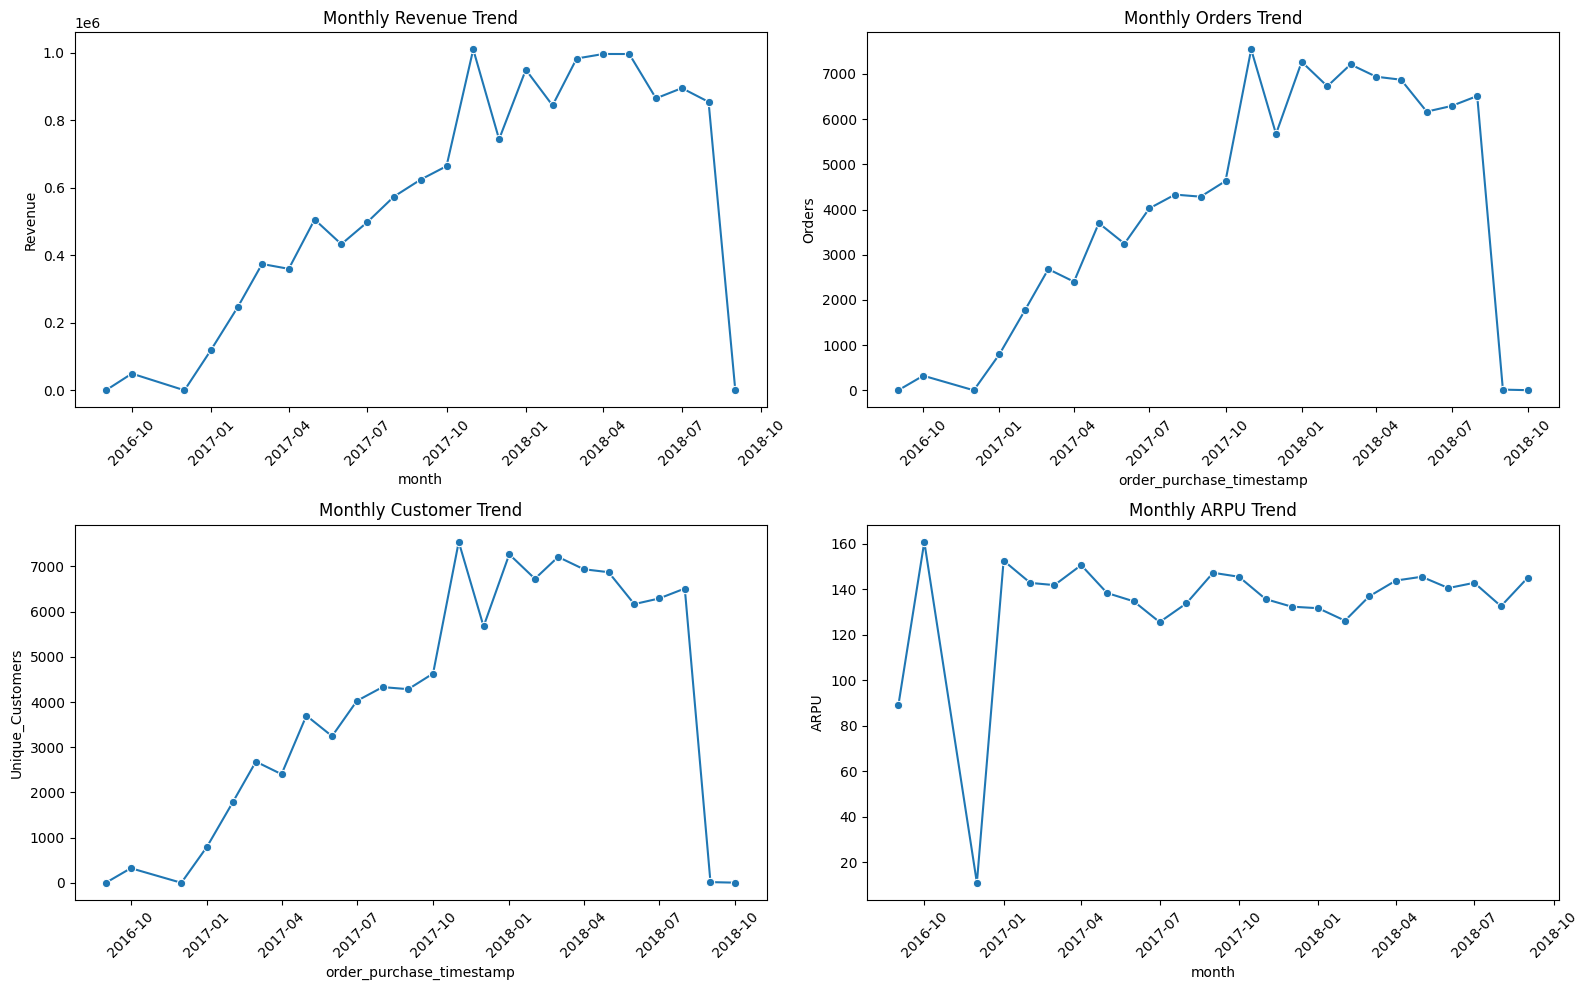

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Ensure datetime and numeric types ---
monthly_revenue['month'] = monthly_revenue['month'].dt.to_timestamp()
monthly_revenue['Revenue'] = pd.to_numeric(monthly_revenue['Revenue'], errors='coerce')

monthly_orders['order_purchase_timestamp'] = monthly_orders['order_purchase_timestamp'].dt.to_timestamp()
monthly_orders['Orders'] = pd.to_numeric(monthly_orders['Orders'], errors='coerce')

monthly_customers['order_purchase_timestamp'] = monthly_customers['order_purchase_timestamp'].dt.to_timestamp()
monthly_customers['Unique_Customers'] = pd.to_numeric(monthly_customers['Unique_Customers'], errors='coerce')

monthly_arpu['month'] = monthly_arpu['month'].dt.to_timestamp()
monthly_arpu['ARPU'] = pd.to_numeric(monthly_arpu['ARPU'], errors='coerce')

# --- Create 2x2 subplot dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue Trend
sns.lineplot(data=monthly_revenue, x='month', y='Revenue', marker='o', ax=axes[0,0])
axes[0,0].set_title("Monthly Revenue Trend")
axes[0,0].tick_params(axis='x', rotation=45)

# Orders Trend
sns.lineplot(data=monthly_orders, x='order_purchase_timestamp', y='Orders', marker='o', ax=axes[0,1])
axes[0,1].set_title("Monthly Orders Trend")
axes[0,1].tick_params(axis='x', rotation=45)

# Customer Trend
sns.lineplot(data=monthly_customers, x='order_purchase_timestamp', y='Unique_Customers', marker='o', ax=axes[1,0])
axes[1,0].set_title("Monthly Customer Trend")
axes[1,0].tick_params(axis='x', rotation=45)

# ARPU Trend
sns.lineplot(data=monthly_arpu, x='month', y='ARPU', marker='o', ax=axes[1,1])
axes[1,1].set_title("Monthly ARPU Trend")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()